# Synthea Claims Risk Model 

**Data sources**
- **[Synthea](https://synthea.mitre.org/)** — an open-source synthetic patient generator. All
  patients, encounters, and costs in this notebook are synthetic; no real patient or employer
  data is used anywhere in this project.
- **DOSM, *National Occupational Injury and Disease Statistics*** — published Malaysian
  government occupational injury rates by industry sector, used to calibrate the industry risk
  loadings in Section 7.

**Scope boundary:** this notebook produces an individual-level *loaded premium* per synthetic
employee.

## 1. Setup & Libraries

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import openpyxl
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font, PatternFill

### Configuration

In [5]:
# Update this to point at your local Synthea CSV export folder.
DATA_DIR = ""  # e.g. "C:/Users/you/Downlaods/data/raw/" if running locally

### Load the raw Synthea extract

Three tables: `patients` (demographics), `encounters` (the claims cost data), `observations` (coded clinical events, including smoking status).

In [6]:
patients = pd.read_csv(DATA_DIR + "patients.csv")
encounters = pd.read_csv(DATA_DIR + "encounters.csv")
observations = pd.read_csv(DATA_DIR + "observations.csv")

print("Files loaded successfully!")

Files loaded successfully!


## 2. Exploratory Data Profiling

### Patients table

In [7]:
# Look at the first 5 rows of the patients table
patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,45f83c51-6809-1aed-b36d-2c99e52ca510,2012-12-28,NaN,999-32-5857,NaN,NaN,NaN,Ryan260,Thomas756,Kertzmann286,...,Lynn,Massachusetts,Essex County,25009.0,1904,42.430530,-70.989559,35750.99,7024.06,128156
1,39d49a31-b430-263a-6edc-8c894e0c7572,2007-05-10,NaN,999-99-8514,S99997469,NaN,Mr.,Zachary28,Jarrod316,Larkin917,...,Gloucester,Massachusetts,Essex County,25009.0,1930,42.581041,-70.667348,53171.02,10668.80,49328
2,bdb89b21-74f3-9161-164b-cc18214a5542,2025-10-05,NaN,999-88-5263,NaN,NaN,NaN,Elmer371,Lenard338,Mayer370,...,North Attleborough,Massachusetts,Bristol County,NaN,0,42.011062,-71.357035,100.00,3673.31,34590
3,09beeb72-72d1-5364-51f6-bceb823f36c1,2009-02-15,NaN,999-89-5508,S99936980,NaN,NaN,Johnie961,Claude750,Erdman779,...,Arlington,Massachusetts,Middlesex County,25017.0,2474,42.386987,-71.142816,28498.61,28130.06,226863
4,81ac9e13-d5e2-164b-e0e7-b3f4bcf8a32d,2009-12-04,NaN,999-26-4649,S99937102,NaN,NaN,Hsiu839,Joan322,Reilly981,...,Boston,Massachusetts,Suffolk County,25025.0,2126,42.367310,-71.083431,58288.11,28639.85,52518


In [8]:
patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 3427 entries, 0 to 3426
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   3427 non-null   str    
 1   BIRTHDATE            3427 non-null   str    
 2   DEATHDATE            427 non-null    str    
 3   SSN                  3427 non-null   str    
 4   DRIVERS              2881 non-null   str    
 5   PASSPORT             2699 non-null   str    
 6   PREFIX               2788 non-null   str    
 7   FIRST                3427 non-null   str    
 8   MIDDLE               2787 non-null   str    
 9   LAST                 3427 non-null   str    
 10  SUFFIX               36 non-null     str    
 11  MAIDEN               935 non-null    str    
 12  MARITAL              2327 non-null   str    
 13  RACE                 3427 non-null   str    
 14  ETHNICITY            3427 non-null   str    
 15  GENDER               3427 non-null   str    
 16 

In [9]:
patients.describe()

,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
count,2553.000000,3427.000000,3427.000000,3427.000000,3.427000e+03,3.427000e+03,3427.000000
mean,25091.227184,1478.052816,42.249228,-71.345025,1.882789e+05,3.376134e+05,121757.920338
std,1186.437963,951.281454,0.291604,0.617806,2.457315e+05,4.552586e+05,174194.059097
min,25001.000000,0.000000,41.241644,-73.380942,1.000000e+02,0.000000e+00,14.000000
25%,25009.000000,0.000000,42.095349,-71.543535,2.488444e+04,1.874318e+04,34503.000000
50%,25017.000000,1852.000000,42.298448,-71.146023,9.988834e+04,1.533794e+05,71745.000000
75%,25025.000000,2151.000000,42.438669,-71.008167,2.300122e+05,5.113749e+05,127183.000000
max,44007.000000,2861.000000,42.894605,-69.925018,1.733415e+06,4.813625e+06,993598.000000


### Encounters table (claims cost)

In [10]:
encounters.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,45f83c51-6809-1aed-4b7d-f5711e8931cf,2016-12-01T21:57:37Z,2016-12-01T22:12:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,936ceb96-2b12-371f-aa68-ee02a9c06f4c,5c60bb3f-ae45-3215-8f23-bb67c68e5b51,b046940f-1664-3047-bca7-dfa76be352a4,wellness,410620009,Well child visit (procedure),136.80,1135.60,760.33,NaN,NaN
1,45f83c51-6809-1aed-fedf-84ba28b27975,2017-08-17T21:57:37Z,2017-08-17T22:12:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,89171335-b9c0-3326-98d6-a837d432b9fd,e7783b4f-6045-376b-a598-c24ba187c387,b046940f-1664-3047-bca7-dfa76be352a4,outpatient,185345009,Encounter for symptom (procedure),85.55,85.55,0.00,65363002.0,Otitis media (disorder)
2,45f83c51-6809-1aed-1e6c-330c08c2ba34,2017-11-03T21:57:37Z,2017-11-03T22:12:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,89171335-b9c0-3326-98d6-a837d432b9fd,e7783b4f-6045-376b-a598-c24ba187c387,b046940f-1664-3047-bca7-dfa76be352a4,ambulatory,185345009,Encounter for symptom (procedure),85.55,3536.75,0.00,195662009.0,Acute viral pharyngitis (disorder)
3,45f83c51-6809-1aed-ac33-b6cd67ede2c1,2017-12-07T21:57:37Z,2017-12-07T22:12:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,936ceb96-2b12-371f-aa68-ee02a9c06f4c,5c60bb3f-ae45-3215-8f23-bb67c68e5b51,b046940f-1664-3047-bca7-dfa76be352a4,wellness,410620009,Well child visit (procedure),136.80,1032.50,175.11,NaN,NaN
4,45f83c51-6809-1aed-df9f-cf678871d468,2018-12-05T21:57:37Z,2018-12-05T22:57:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,c1986c0c-f756-3596-8f90-08adacf220fe,878bb1f5-5ae9-352f-9a06-8c9a79f87da9,b046940f-1664-3047-bca7-dfa76be352a4,emergency,50849002,Emergency room admission (procedure),146.18,8573.99,2879.99,312608009.0,Laceration - injury (disorder)


In [11]:
encounters.info()

<class 'pandas.DataFrame'>
RangeIndex: 208415 entries, 0 to 208414
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Id                   208415 non-null  str    
 1   START                208415 non-null  str    
 2   STOP                 208415 non-null  str    
 3   PATIENT              208415 non-null  str    
 4   ORGANIZATION         208415 non-null  str    
 5   PROVIDER             208415 non-null  str    
 6   PAYER                208415 non-null  str    
 7   ENCOUNTERCLASS       208415 non-null  str    
 8   CODE                 208415 non-null  int64  
 9   DESCRIPTION          208415 non-null  str    
 10  BASE_ENCOUNTER_COST  208415 non-null  float64
 11  TOTAL_CLAIM_COST     208415 non-null  float64
 12  PAYER_COVERAGE       208415 non-null  float64
 13  REASONCODE           130115 non-null  float64
 14  REASONDESCRIPTION    130115 non-null  str    
dtypes: float64(4), int64(1), str

In [12]:
encounters.describe()

,CODE,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE
count,2.084150e+05,208415.000000,208415.000000,208415.000000,1.301150e+05
mean,9.156435e+10,111.625634,2666.609815,1924.529135,5.507795e+11
std,6.431925e+12,27.394474,7212.558349,6101.497846,1.047962e+13
min,1.505002e+06,75.000000,75.000000,0.000000,1.734006e+06
25%,1.853450e+08,85.550000,535.870000,0.000000,6.638301e+07
50%,1.853470e+08,85.550000,914.780000,500.870000,1.036970e+08
75%,3.083350e+08,142.580000,1791.030000,1276.380000,4.318570e+08
max,4.531310e+14,146.180000,433741.420000,346993.130000,4.425710e+14


### Distribution of raw claim costs

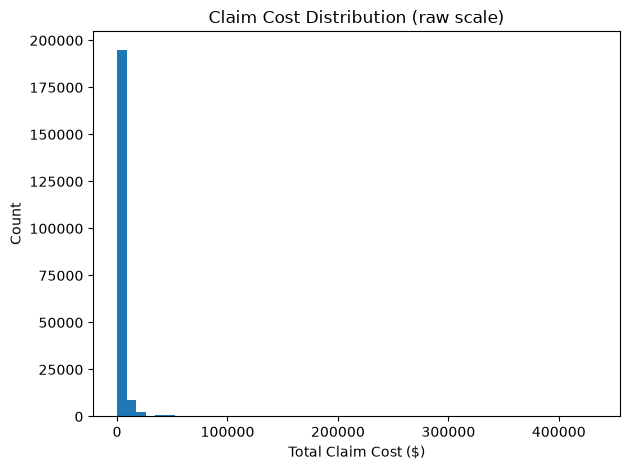

In [24]:
encounters['TOTAL_CLAIM_COST'].describe()

# Raw-scale histogram 
plt.hist(encounters['TOTAL_CLAIM_COST'], bins=50, color='#1f77b4')
plt.title('Claim Cost Distribution (raw scale)')
plt.xlabel('Total Claim Cost ($)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

> There is an extreme right-skewness shown and a long tail typical of medical claims. The distribution will be plotted again with above $0 filter and a log10-scale will be applied.

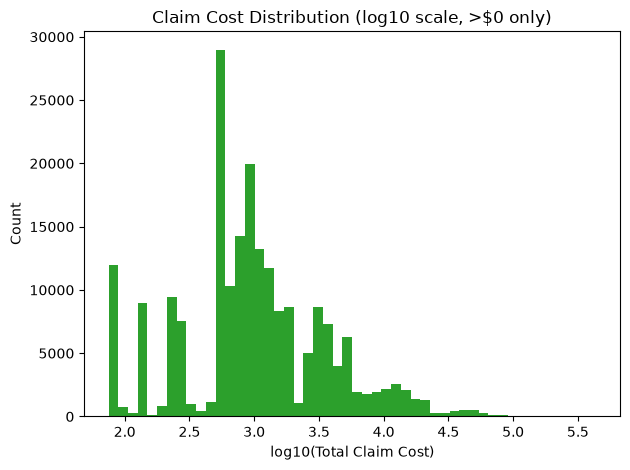

In [25]:
# Log-scale histogram 
positive_claims = encounters.loc[encounters['TOTAL_CLAIM_COST'] > 0, 'TOTAL_CLAIM_COST']
plt.hist(np.log10(positive_claims), bins=50, color='#2ca02c')
plt.title('Claim Cost Distribution (log10 scale, >$0 only)')
plt.xlabel('log10(Total Claim Cost)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

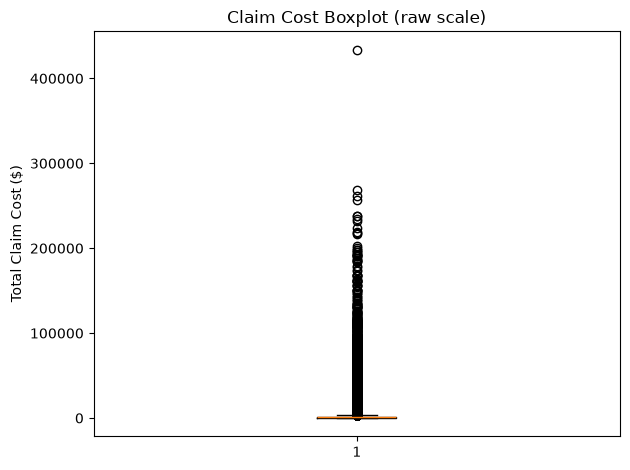

Share of encounters with exactly $0 claim cost: 0.0%


In [26]:
# Boxplot, raw scale 
plt.boxplot(encounters['TOTAL_CLAIM_COST'], orientation='vertical')
plt.title('Claim Cost Boxplot (raw scale)')
plt.ylabel('Total Claim Cost ($)')

plt.tight_layout()
plt.show()

zero_claim_share = (encounters['TOTAL_CLAIM_COST'] == 0).mean()
print(f"Share of encounters with exactly $0 claim cost: {zero_claim_share:.1%}")

### Observations table (clinical events)

In [13]:
observations.head()

,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2016-12-01T21:57:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,45f83c51-6809-1aed-4b7d-f5711e8931cf,vital-signs,8302-2,Body Height,103.2,cm,numeric
1,2016-12-01T21:57:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,45f83c51-6809-1aed-4b7d-f5711e8931cf,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,1.0,{score},numeric
2,2016-12-01T21:57:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,45f83c51-6809-1aed-4b7d-f5711e8931cf,vital-signs,29463-7,Body Weight,14.5,kg,numeric
3,2016-12-01T21:57:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,45f83c51-6809-1aed-4b7d-f5711e8931cf,vital-signs,77606-2,Weight-for-length Per age and sex,2.4,%,numeric
4,2016-12-01T21:57:37Z,45f83c51-6809-1aed-b36d-2c99e52ca510,45f83c51-6809-1aed-4b7d-f5711e8931cf,vital-signs,8289-1,Head Occipital-frontal circumference Percentile,64.7,%,numeric


In [14]:
observations.info()

<class 'pandas.DataFrame'>
RangeIndex: 2812942 entries, 0 to 2812941
Data columns (total 9 columns):
 #   Column       Dtype
---  ------       -----
 0   DATE         str  
 1   PATIENT      str  
 2   ENCOUNTER    str  
 3   CATEGORY     str  
 4   CODE         str  
 5   DESCRIPTION  str  
 6   VALUE        str  
 7   UNITS        str  
 8   TYPE         str  
dtypes: str(9)
memory usage: 193.1 MB


## 3. Preparing the Claims Window

In [15]:
# Converting 'START' column to Date
encounters['START'] = pd.to_datetime(encounters['START'])

# Finding the oldest and newest dates in the dataset
oldest_date = encounters['START'].min()
newest_date = encounters['START'].max()

print(f"The oldest encounter is from: {oldest_date}")
print(f"The newest encounter is from: {newest_date}")

The oldest encounter is from: 1919-02-03 11:30:07+00:00
The newest encounter is from: 2026-08-17 06:59:44+00:00


In [16]:
pd.isna(patients['DEATHDATE'])

0        True
1        True
2        True
3        True
4        True
        ...  
3422    False
3423     True
3424    False
3425    False
3426     True
Name: DEATHDATE, Length: 3427, dtype: bool

## 4. Building the Relational Layer (SQLite)

In [17]:
# Connect to a local SQLite database (creates the file if it doesn't exist)
conn = sqlite3.connect("eb_pricing.db")

# Reuse the DataFrames already loaded above instead of re-reading from disk.
patients.to_sql("patients", conn, if_exists="replace", index=False)
encounters.to_sql("encounters", conn, if_exists="replace", index=False)
observations.to_sql("observations", conn, if_exists="replace", index=False)

2812942

### Defining the Active Census

The snapshot date is set to '2026-01-01' where age is calculated and setting age limit between 18 and 65

count    1919.000000
mean       40.841063
std        13.785761
min        18.000000
25%        28.000000
50%        41.000000
75%        53.000000
max        65.000000
Name: age, dtype: float64


<Axes: >

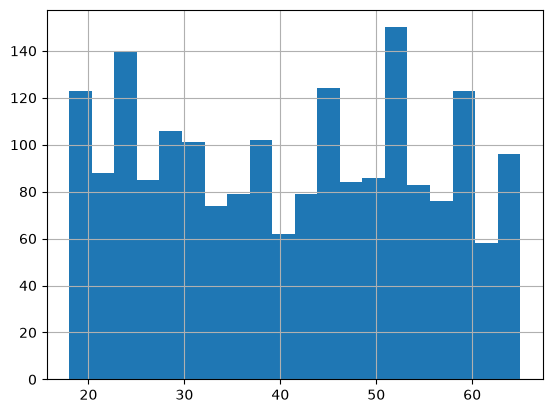

In [18]:
# Save active_census as a permanent View in SQLite
conn.execute("""
CREATE VIEW IF NOT EXISTS active_census AS
SELECT 
    Id AS patient_id,
    GENDER,
    BIRTHDATE,
    CAST((julianday('2026-01-01') - julianday(BIRTHDATE)) / 365.25 AS INT) AS age
FROM patients
WHERE DEATHDATE IS NULL 
  AND CAST((julianday('2026-01-01') - julianday(BIRTHDATE)) / 365.25 AS INT) BETWEEN 18 AND 65;
""")
conn.commit()

# Query the view to load the filtered census
query_census = "SELECT * FROM active_census;"
df_census = pd.read_sql(query_census, conn)

# View statistics and plot distribution
print(df_census['age'].describe())
df_census['age'].hist(bins=20)

## 5. Aggregating Historical Claims

Two versions follow: an early look at the raw multi-year shape of the data, and the corrected version that actually feeds the model.

### Original Approach

group claims by `claim_year`, producing many rows per patient (26,787 rows across ~1,919 patients in the original run).

In [19]:
# Querying claims using the newly created View
query_claims = """
SELECT 
    c.patient_id,
    c.age,
    c.GENDER,
    strftime('%Y', e.START) AS claim_year,
    COALESCE(SUM(e.TOTAL_CLAIM_COST), 0) AS total_claims
FROM active_census AS c
LEFT JOIN encounters AS e 
    ON c.patient_id = e.PATIENT
GROUP BY c.patient_id, c.age, c.GENDER, claim_year;
"""

df_result = pd.read_sql(query_claims, conn)
print(df_result.describe())
df_result.head(10)

                age   total_claims
count  26787.000000   26787.000000
mean      43.533841   10590.094611
std       13.659667   26112.717158
min       18.000000      75.000000
25%       32.000000     914.780000
50%       46.000000    1897.010000
75%       55.000000    6606.600000
max       65.000000  931032.930000


,patient_id,age,GENDER,claim_year,total_claims
0,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,1975,602.50
1,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,1992,704.20
2,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,1996,1061.68
3,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2005,1130.48
4,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2010,704.20
5,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2013,1033.63
6,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2014,914.78
7,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2016,704.20
8,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2017,1262.97
9,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2018,704.20


## 6. Deriving Smoking Status from Clinical Observations

Smoking is a coded clinical observation (LOINC `72166-2`)

In [20]:
# Query distinct raw text entries for tobacco smoking status (LOINC 72166-2)
query_smoker_raw = """
SELECT DISTINCT VALUE
FROM observations
WHERE CODE = '72166-2';
"""

df_smoker_raw = pd.read_sql(query_smoker_raw, conn)
print(df_smoker_raw)

                            VALUE
0  Never smoked tobacco (finding)
1             Ex-smoker (finding)
2  Smokes tobacco daily (finding)


In [21]:
# Create or replace a view that maps patients to their smoking status
conn.execute("""
CREATE VIEW IF NOT EXISTS patient_smoker_status AS
SELECT 
    PATIENT AS patient_id,
    MAX(CASE WHEN VALUE = 'Smokes tobacco daily (finding)' THEN 1 ELSE 0 END) AS is_smoker
FROM observations
WHERE CODE = '72166-2'
GROUP BY PATIENT;
""")
conn.commit()

# Verify the binary distribution
df_smoker_dist = pd.read_sql("SELECT is_smoker, COUNT(*) as count FROM patient_smoker_status GROUP BY is_smoker;", conn)
print(df_smoker_dist)

   is_smoker  count
0          0   3360
1          1     67


> **Note:** ~2% of patients are flagged as daily smokers in this sample which is noticeably lower than typical real-world adult smoking prevalence (~15–20%). Worth keeping in mind when interpreting the smoker coefficient in Section 8.

### Single-policy-year panel (correct version)
Restrict to a single shared policy year — `POLICY_YEAR = 2025`, the last full calendar year before the snapshot and produce exactly **one row per patient**.

In [22]:
POLICY_YEAR = '2025'

query_final_panel = """
SELECT 
    c.patient_id,
    c.age,
    c.GENDER,
    COALESCE(s.is_smoker, 0) AS is_smoker,
    COALESCE(SUM(e.TOTAL_CLAIM_COST), 0) AS total_claims
FROM active_census c
LEFT JOIN patient_smoker_status s 
    ON c.patient_id = s.patient_id
LEFT JOIN encounters e 
    ON c.patient_id = e.PATIENT
    AND strftime('%Y', e.START) = ?
GROUP BY c.patient_id, c.age, c.GENDER, s.is_smoker;
"""

df_model_data = pd.read_sql(query_final_panel, conn, params=(POLICY_YEAR,))
print(f"Rows: {len(df_model_data)}  (one per active_census member -- was one per "
      f"patient-year before the fix)")
print(df_model_data.head())


Rows: 1919  (one per active_census member -- was one per patient-year before the fix)
                             patient_id  age GENDER  is_smoker  total_claims
0  000d0ab4-8758-25f9-270d-4b9ac627bcc4   51      M          0       4523.36
1  004ee5fe-4dec-030f-dd84-6217f57f04de   50      M          0      22253.80
2  00ec7649-20ca-53c9-39fd-7228cc2f3ec0   55      F          0       6759.84
3  00fdbb6b-68a7-3ca9-c54e-e0349500cb06   26      M          0       1152.42
4  01026cb4-ae34-6a5a-df71-f1d2ad04c94a   20      M          0          0.00


## 7. Malaysian Occupational Risk Calibration (DOSM Benchmark)

Applying the industry risk multiplier with real, published Malaysian occupational injury rates by sector (DOSM, national average 2.46 per 1,000 workers), banded into four occupational risk classes.

In [27]:
# Reconstructed DOSM Occupational Injury Benchmark (Source: Table 2.b - Jumlah Column)
# National Average Rate = 2.46 per 1,000 workers
NATIONAL_AVG_INJURY_RATE = 2.46

dosm_data = {
    "industry_sector": [
        "Hotels and Restaurants",
        "Services",
        "Wholesale and Retail Trades",
        "Agriculture, Forestry and Fishing",
        "Utilities",
        "Transport, Storage and Communication",
        "Mining and Quarrying",
        "Finance, Insurance, Real Estate and Business Services",
        "Manufacturing",
        "Construction"
    ],
    "dosm_injury_rate_per_1k": [0.48, 1.14, 1.31, 1.64, 2.75, 2.79, 2.84, 2.97, 3.98, 4.19],
}

df_dosm = pd.DataFrame(dosm_data)

# Continuous multiplier: each industry's rate expressed directly as a ratio to the national
# average, instead of banded into discrete classes. Hotels (0.48) becomes ~0.20x, Construction
# (4.19) becomes ~1.70x -- preserving DOSM's real ~8.7x spread between safest and riskiest
# sectors, rather than compressing it into an arbitrary 0.80-1.50 range.
df_dosm['risk_multiplier'] = df_dosm['dosm_injury_rate_per_1k'] / NATIONAL_AVG_INJURY_RATE

# Write to CSV and persist directly to your SQLite database
df_dosm.to_csv("dosm_industry_risk.csv", index=False)
df_dosm.to_sql("dosm_industry_risk", conn, if_exists="replace", index=False)

print(df_dosm)

                                     industry_sector  dosm_injury_rate_per_1k  \
0                             Hotels and Restaurants                     0.48   
1                                           Services                     1.14   
2                        Wholesale and Retail Trades                     1.31   
3                  Agriculture, Forestry and Fishing                     1.64   
4                                          Utilities                     2.75   
5               Transport, Storage and Communication                     2.79   
6                               Mining and Quarrying                     2.84   
7  Finance, Insurance, Real Estate and Business S...                     2.97   
8                                      Manufacturing                     3.98   
9                                       Construction                     4.19   

   risk_multiplier  
0         0.195122  
1         0.463415  
2         0.532520  
3         0.666667  
4  

### First-pass industry loading (superseded below)

This early version applies the DOSM risk multiplier directly to the raw historical `total_claims`. Kept to show the iteration and superseded in Section 9, which applies the multiplier to the model's *predicted* baseline instead.

In [28]:
# Randomly assign a DOSM industry sector to each member
industries = df_dosm['industry_sector'].values
df_model_data['industry_sector'] = np.random.choice(industries, size=len(df_model_data))

# Join the DOSM risk multipliers into your dataset
df_model_data = df_model_data.merge(
    df_dosm[['industry_sector', 'risk_multiplier']], 
    on='industry_sector', 
    how='left'
)

# Apply occupational loading factor to GLM expected baseline claim
df_model_data['loaded_premium'] = df_model_data['total_claims'] * df_model_data['risk_multiplier']

## 8. Fitting the Actuarial Baseline Model (Poisson GLM)

In [30]:
# Prepare data and convert GENDER to a binary dummy variable
df_model_data['is_female'] = (df_model_data['GENDER'] == 'F').astype(int)

# Fit an actuarial Poisson GLM for expected claims
glm_formula = "total_claims ~ age + is_female + is_smoker"
glm_model = smf.glm(formula=glm_formula, data=df_model_data, family=sm.families.Poisson()).fit()


# Print the model summary coefficients
print(glm_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           total_claims   No. Observations:                 1919
Model:                            GLM   Df Residuals:                     1915
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.8543e+07
Date:                Sun, 30 Aug 2026   Deviance:                   5.7069e+07
Time:                        20:49:20   Pearson chi2:                 2.31e+08
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.1387      0.001   1.31e+04      0.0

## 9. Applying the Corrected Industry and Employer Group Loading

The DOSM multiplier applied to `pred_base_claims` (the model's individual-level prediction), not the raw historical value. This keeps individual risk (the GLM) and portfolio-level risk (the DOSM multiplier) separate. 

In [31]:
# Predict baseline claims from the Poisson GLM
df_model_data['pred_base_claims'] = glm_model.predict(df_model_data)

# Assign simulated corporate industry sectors
np.random.seed(42)
industries = df_dosm['industry_sector'].values
df_model_data['industry_sector'] = np.random.choice(industries, size=len(df_model_data))

# Direct dictionary mapping (avoids merge/duplicate column errors)
dosm_map = dict(zip(df_dosm['industry_sector'], df_dosm['risk_multiplier']))
df_model_data['risk_multiplier'] = df_model_data['industry_sector'].map(dosm_map)

# Calculate Final Actuarial Group Premium
df_model_data['final_loaded_premium'] = df_model_data['pred_base_claims'] * df_model_data['risk_multiplier']

# Verify top rows
print(df_model_data[['patient_id', 'age', 'is_smoker', 'industry_sector', 'pred_base_claims', 'risk_multiplier', 'final_loaded_premium']].head())

                             patient_id  age  is_smoker  \
0  000d0ab4-8758-25f9-270d-4b9ac627bcc4   51          0   
1  004ee5fe-4dec-030f-dd84-6217f57f04de   50          0   
2  00ec7649-20ca-53c9-39fd-7228cc2f3ec0   55          0   
3  00fdbb6b-68a7-3ca9-c54e-e0349500cb06   26          0   
4  01026cb4-ae34-6a5a-df71-f1d2ad04c94a   20          0   

                                     industry_sector  pred_base_claims  \
0                               Mining and Quarrying       6472.466471   
1                  Agriculture, Forestry and Fishing       6518.755212   
2  Finance, Insurance, Real Estate and Business S...      18108.554033   
3                                          Utilities       7734.663093   
4                               Mining and Quarrying       8072.547023   

   risk_multiplier  final_loaded_premium  
0         1.154472           7472.278365  
1         0.666667           4345.836808  
2         1.207317          21862.766455  
3         1.117886          

Simulating Employer Groups (Company_ID)

In [32]:
np.random.seed(7)  # separate seed stream from the industry assignment (seed=42)

n_employees = len(df_model_data)
MIN_GROUP_SIZE = 5  # insurers generally won't quote a standalone group below this

company_sizes = []
running_total = 0
while running_total < n_employees:
    size = int(np.random.lognormal(mean=3.0, sigma=1.1))
    size = max(size, MIN_GROUP_SIZE)
    if running_total + size > n_employees:
        size = n_employees - running_total  # trim the last group to exactly fill the census
    company_sizes.append(size)
    running_total += size

# Merge a too-small final group into the previous one rather than leaving an
# under-minimum standalone company.
if len(company_sizes) > 1 and company_sizes[-1] < MIN_GROUP_SIZE:
    company_sizes[-2] += company_sizes.pop()

n_companies = len(company_sizes)
company_ids = [f"COMP_{i+1:04d}" for i in range(n_companies)]

# Repeat each Company_ID by its group size, then shuffle so membership isn't
# correlated with row order (e.g. patient_id sequence).
assignment = np.repeat(company_ids, company_sizes)
np.random.shuffle(assignment)
df_model_data['Company_ID'] = assignment

print(f"Generated {n_companies} synthetic employer groups covering {n_employees} lives")
print(df_model_data.groupby('Company_ID').size().describe())

Generated 51 synthetic employer groups covering 1919 lives
count     51.000000
mean      37.627451
std       49.593129
min        5.000000
25%        8.500000
50%       19.000000
75%       36.500000
max      238.000000
dtype: float64


## 10. Validating the Model Visually

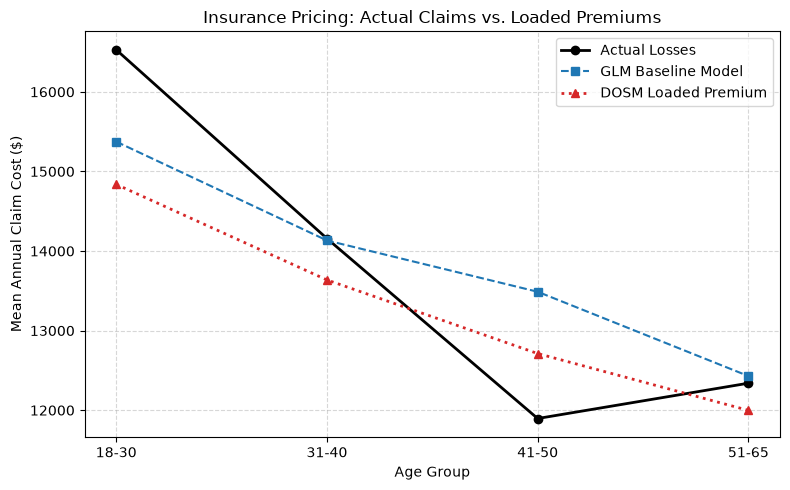

In [33]:
# Group members into actuarial age bands
df_model_data['age_group'] = pd.cut(
    df_model_data['age'], 
    bins=[17, 30, 40, 50, 65], 
    labels=['18-30', '31-40', '41-50', '51-65']
)

# Aggregate mean costs per age bracket
chart_data = df_model_data.groupby('age_group', observed=False)[
    ['total_claims', 'pred_base_claims', 'final_loaded_premium']
].mean()

# Plot Actuals vs Baseline vs Loaded Premium
plt.figure(figsize=(8, 5))
plt.plot(chart_data.index, chart_data['total_claims'], label='Actual Losses', marker='o', color='black', linewidth=2)
plt.plot(chart_data.index, chart_data['pred_base_claims'], label='GLM Baseline Model', linestyle='--', marker='s', color='#1f77b4')
plt.plot(chart_data.index, chart_data['final_loaded_premium'], label='DOSM Loaded Premium', linestyle=':', marker='^', color='#d62728', linewidth=2)

plt.title('Insurance Pricing: Actual Claims vs. Loaded Premiums')
plt.xlabel('Age Group')
plt.ylabel('Mean Annual Claim Cost ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save chart image for README inclusion
plt.savefig('actual_vs_predicted_claims.png', dpi=300)
plt.show()

## 11. Benchmarking Against a Flexible ML Model (XGBoost)

In [34]:
features = ['age', 'is_female', 'is_smoker']
X = df_model_data[features]
y = df_model_data['total_claims']

# XGBoost, Poisson objective -- same distributional assumption as the GLM baseline,
# isolates the effect of model flexibility alone.
xgb_model_poisson = xgb.XGBRegressor(
    objective='count:poisson', n_estimators=100, learning_rate=0.05,
    max_depth=3, random_state=42
)
xgb_model_poisson.fit(X, y)
df_model_data['pred_xgb_poisson_claims'] = xgb_model_poisson.predict(X)

# XGBoost, Tweedie objective -- correctly-specified distribution, var_power matches
# the GLM Tweedie in Section 12 so the two Tweedie models are comparable too.
xgb_model_tweedie = xgb.XGBRegressor(
    objective='reg:tweedie', tweedie_variance_power=1.2, n_estimators=100,
    learning_rate=0.05, max_depth=3, random_state=42
)
xgb_model_tweedie.fit(X, y)
df_model_data['pred_xgb_tweedie_claims'] = xgb_model_tweedie.predict(X)

glm_rmse = root_mean_squared_error(y, df_model_data['pred_base_claims'])
xgb_poisson_rmse = root_mean_squared_error(y, df_model_data['pred_xgb_poisson_claims'])
xgb_tweedie_rmse = root_mean_squared_error(y, df_model_data['pred_xgb_tweedie_claims'])
glm_mae = mean_absolute_error(y, df_model_data['pred_base_claims'])
xgb_poisson_mae = mean_absolute_error(y, df_model_data['pred_xgb_poisson_claims'])
xgb_tweedie_mae = mean_absolute_error(y, df_model_data['pred_xgb_tweedie_claims'])

print(f"GLM Poisson      -> RMSE: ${glm_rmse:,.2f} | MAE: ${glm_mae:,.2f}")
print(f"XGBoost Poisson  -> RMSE: ${xgb_poisson_rmse:,.2f} | MAE: ${xgb_poisson_mae:,.2f}")
print(f"XGBoost Tweedie  -> RMSE: ${xgb_tweedie_rmse:,.2f} | MAE: ${xgb_tweedie_mae:,.2f}")

GLM Poisson      -> RMSE: $34,343.77 | MAE: $15,324.60
XGBoost Poisson  -> RMSE: $33,238.86 | MAE: $14,631.82
XGBoost Tweedie  -> RMSE: $33,026.19 | MAE: $14,418.84


## 12. Distributional Fit Check — Tweedie GLM

In [35]:
tweedie_formula = "total_claims ~ age + is_female + is_smoker"
tweedie_model = smf.glm(
    formula=tweedie_formula, data=df_model_data,
    family=sm.families.Tweedie(var_power=1.2, link=sm.families.links.Log()) #
).fit()

df_model_data['pred_tweedie_claims'] = tweedie_model.predict(df_model_data)

tweedie_rmse = root_mean_squared_error(y, df_model_data['pred_tweedie_claims'])
tweedie_mae = mean_absolute_error(y, df_model_data['pred_tweedie_claims'])

print(f"GLM Poisson      -> RMSE: ${glm_rmse:,.2f} | MAE: ${glm_mae:,.2f}")
print(f"GLM Tweedie      -> RMSE: ${tweedie_rmse:,.2f} | MAE: ${tweedie_mae:,.2f}")
print(f"XGBoost Poisson  -> RMSE: ${xgb_poisson_rmse:,.2f} | MAE: ${xgb_poisson_mae:,.2f}")
print(f"XGBoost Tweedie  -> RMSE: ${xgb_tweedie_rmse:,.2f} | MAE: ${xgb_tweedie_mae:,.2f}")

GLM Poisson      -> RMSE: $34,343.77 | MAE: $15,324.60
GLM Tweedie      -> RMSE: $34,389.20 | MAE: $15,334.16
XGBoost Poisson  -> RMSE: $33,238.86 | MAE: $14,631.82
XGBoost Tweedie  -> RMSE: $33,026.19 | MAE: $14,418.84


### Inspecting the Tweedie fit 

In [36]:
# .summary() raises NotImplementedError for Tweedie at this var_power -- these are the
# direct equivalents, available because they come from the IRLS fit, not the log-likelihood.
print("Coefficients:\n", tweedie_model.params)
print("\nStandard errors:\n", tweedie_model.bse)
print("\nP-values:\n", tweedie_model.pvalues)

Coefficients:
 Intercept    9.028581
age         -0.004131
is_female    1.043661
is_smoker    0.090034
dtype: float64

Standard errors:
 Intercept    0.246423
age          0.005185
is_female    0.154048
is_smoker    0.436834
dtype: float64

P-values:
 Intercept    6.952593e-294
age           4.256128e-01
is_female     1.244690e-11
is_smoker     8.367083e-01
dtype: float64


## 13. Model Comparison Visualization

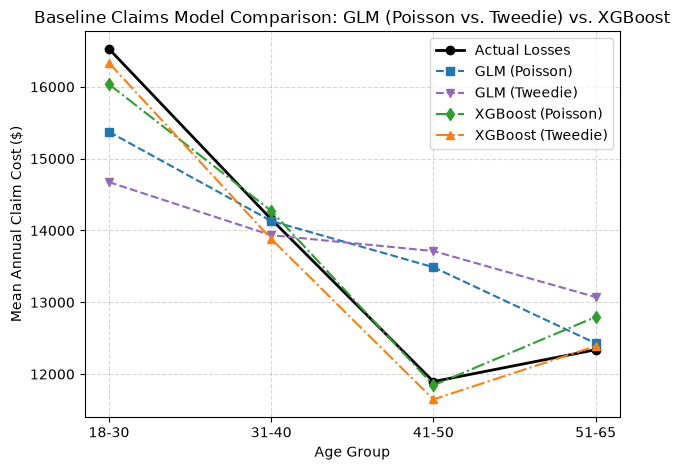

In [37]:
# Aggregate mean actuals and predictions across age groups
chart_comp = df_model_data.groupby('age_group', observed=False)[
    ['total_claims', 'pred_base_claims', 'pred_tweedie_claims',
     'pred_xgb_poisson_claims', 'pred_xgb_tweedie_claims']
].mean()

plt.plot(chart_comp.index, chart_comp['total_claims'], label='Actual Losses', marker='o', color='black', linewidth=2)
plt.plot(chart_comp.index, chart_comp['pred_base_claims'], label='GLM (Poisson)', linestyle='--', marker='s', color='#1f77b4')
plt.plot(chart_comp.index, chart_comp['pred_tweedie_claims'], label='GLM (Tweedie)', linestyle='--', marker='v', color='#9467bd')
plt.plot(chart_comp.index, chart_comp['pred_xgb_poisson_claims'], label='XGBoost (Poisson)', linestyle='-.', marker='d', color='#2ca02c')
plt.plot(chart_comp.index, chart_comp['pred_xgb_tweedie_claims'], label='XGBoost (Tweedie)', linestyle='-.', marker='^', color='#ff7f0e')

plt.title('Baseline Claims Model Comparison: GLM (Poisson vs. Tweedie) vs. XGBoost')
plt.xlabel('Age Group')
plt.ylabel('Mean Annual Claim Cost ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save image for GitHub portfolio
plt.savefig('glm_vs_xgboost_comparison.png', dpi=300)
plt.show()


> **Note:** all four models above are fit and scored on the same data, with no train/test split. XGBoost's edge over both GLMs may partly reflect its greater flexibility fitting training-set noise rather than genuine generalization.

## 14. Statistical Significance Test (Is XGBoost Actually Better Than the GLM)?

### Train/test split, refit on training data only

In [38]:
from sklearn.model_selection import train_test_split
from scipy import stats

train_idx, test_idx = train_test_split(df_model_data.index, test_size=0.2, random_state=42)
df_train = df_model_data.loc[train_idx].copy()
df_test = df_model_data.loc[test_idx].copy()

glm_formula_test = "total_claims ~ age + is_female + is_smoker"
glm_train = smf.glm(formula=glm_formula_test, data=df_train, family=sm.families.Poisson()).fit()

features_test = ['age', 'is_female', 'is_smoker']
X_train, X_test = df_train[features_test], df_test[features_test]
y_train, y_test = df_train['total_claims'], df_test['total_claims']

xgb_train = xgb.XGBRegressor(objective='count:poisson', n_estimators=100,
                              learning_rate=0.05, max_depth=3, random_state=42)
xgb_train.fit(X_train, y_train)

glm_test_pred = glm_train.predict(df_test)
xgb_test_pred = xgb_train.predict(X_test)

glm_test_mae = mean_absolute_error(y_test, glm_test_pred)
xgb_test_mae = mean_absolute_error(y_test, xgb_test_pred)
print(f"Held-out MAE -- GLM: ${glm_test_mae:,.2f} | XGBoost: ${xgb_test_mae:,.2f}")


Held-out MAE -- GLM: $15,725.06 | XGBoost: $15,789.90


### The paired significance test, on held-out errors only

In [39]:
errors_glm = np.abs(y_test - glm_test_pred)
errors_xgb = np.abs(y_test - xgb_test_pred)

t_stat, t_pvalue = stats.ttest_rel(errors_glm, errors_xgb)
w_stat, w_pvalue = stats.wilcoxon(errors_glm, errors_xgb)

print(f"Paired t-test:        t = {t_stat:.3f}, p = {t_pvalue:.4f}")
print(f"Wilcoxon signed-rank: W = {w_stat:.1f}, p = {w_pvalue:.4f}")

Paired t-test:        t = -0.142, p = 0.8875
Wilcoxon signed-rank: W = 31221.0, p = 0.0084


### Validating the result and deciding whether to promote XGBoost

The decision rule: only promote XGBoost if it's **both** more accurate on held-out data *and*
that gap is statistically significant (p < 0.05), a lower held-out MAE with a large p-value
could just as easily be noise from this particular 80/20 split, not a real, repeatable
advantage.

If XGBoost wins on both counts, it's refit on the **full** dataset (not just the 80% training
split) before being promoted. The train/test split exists to validate *which model
architecture* to trust, not to throw away 20% of real data from the model that actually goes
into production. If it doesn't win on both counts, `pred_base_claims` simply keeps the GLM's
existing full-data prediction from Sections 8–9.

In [40]:
SIGNIFICANCE_LEVEL = 0.05
xgb_wins = (xgb_test_mae < glm_test_mae) and (w_pvalue < SIGNIFICANCE_LEVEL)

if xgb_wins:
    print("Decision: XGBoost is significantly more accurate on held-out data -- promoting it.")
    # xgb_model_poisson (Section 11) was already fit on the full dataset with these exact
    # hyperparameters -- refitting it here would just be computing the same thing twice.
    # Reuse its existing predictions instead of training a third, identical model.
    df_model_data['pred_base_claims'] = df_model_data['pred_xgb_poisson_claims']
    chosen_model_name = "XGBoost (Poisson), promoted in Section 14"
else:
    print("Decision: No significant, genuine improvement from XGBoost on held-out data --")
    print("keeping the GLM. Interpretability is free when accuracy is a tie.")
    chosen_model_name = "GLM (Poisson)"

# Re-apply Section 9's industry loading using whichever prediction pred_base_claims now
# holds -- this keeps the rest of the notebook (company grouping, RM rescaling below)
# correct regardless of which branch above ran.
df_model_data['final_loaded_premium'] = (
    df_model_data['pred_base_claims'] * df_model_data['risk_multiplier']
)
print(f"\nModel used for pricing going forward: {chosen_model_name}")

Decision: No significant, genuine improvement from XGBoost on held-out data --
keeping the GLM. Interpretability is free when accuracy is a tie.

Model used for pricing going forward: GLM (Poisson)


## 15. Rescaling to Malaysian Ringgit


In [41]:
RM_TARGET_MEAN = 1800

rm_scale_factor = RM_TARGET_MEAN / df_model_data['final_loaded_premium'].mean()
df_model_data['final_loaded_premium_rm'] = df_model_data['final_loaded_premium'] * rm_scale_factor

print(f"Scale factor applied: {rm_scale_factor:.6f}")
print(df_model_data['final_loaded_premium_rm'].describe())

# Export the member-level output ready for the Excel quote schedule stage
export_cols = ['patient_id', 'Company_ID', 'age', 'GENDER', 'is_smoker', 'industry_sector',
               'risk_multiplier', 'final_loaded_premium_rm']
df_model_data[export_cols].to_csv('member_level_pricing_output.csv', index=False)
print("\nWrote member_level_pricing_output.csv -- ready for the Excel quote schedule stage.")


Scale factor applied: 0.135239
count    1919.000000
mean     1800.000000
std      1317.638078
min       155.684061
25%       895.129349
50%      1337.704860
75%      2837.252658
max      5789.576994
Name: final_loaded_premium_rm, dtype: float64

Wrote member_level_pricing_output.csv -- ready for the Excel quote schedule stage.


In [42]:
import pandas as pd
import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

# 1. Select a specific company census (e.g., COMP_0001)
target_company_id = "COMP_0001"
company_df = df_model_data[df_model_data['Company_ID'] == target_company_id].copy()

# 2. Aggregate Census by Age Group & Gender Tiers
summary_table = company_df.groupby(['age_group', 'GENDER'], observed=False).agg(
    Headcount=('patient_id', 'count'),
    Avg_Rate_RM=('final_loaded_premium_rm', 'mean'),
    Total_Premium_RM=('final_loaded_premium_rm', 'sum')
).reset_index()

# Filter out empty demographic tiers
summary_table = summary_table[summary_table['Headcount'] > 0]

# 3. Create Excel Workbook & Sheet
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Quote Schedule"
ws.views.sheetView[0].showGridLines = True

# Styling Palettes
navy_fill = PatternFill(start_color="1B365D", end_color="1B365D", fill_type="solid")
header_font = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
title_font = Font(name="Calibri", size=16, bold=True, color="1B365D")
bold_font = Font(name="Calibri", size=11, bold=True)
regular_font = Font(name="Calibri", size=11)

thin_border = Border(
    left=Side(style='thin', color='D9D9D9'),
    right=Side(style='thin', color='D9D9D9'),
    top=Side(style='thin', color='D9D9D9'),
    bottom=Side(style='thin', color='D9D9D9')
)
double_bottom_border = Border(
    top=Side(style='thin', color='000000'),
    bottom=Side(style='double', color='000000')
)

# --- HEADER BLOCK ---
ws['A1'] = "GROUP HOSPITALIZATION & SURGICAL (GHS) QUOTE SCHEDULE"
ws['A1'].font = title_font

ws['A3'] = "Client Name:"
ws['B3'] = target_company_id
ws['A4'] = "Policy Period:"
ws['B4'] = "01-Jan-2026 to 31-Dec-2026"
ws['A5'] = "Coverage Tier:"
ws['B5'] = "Comprehensive Enterprise Care"

for r in range(3, 6):
    ws[f'A{r}'].font = bold_font
    ws[f'B{r}'].font = regular_font

# --- PRICING SCHEDULE TABLE ---
headers = ["Age Band", "Gender", "Headcount", "Average Rate / Life (RM)", "Total Premium (RM)"]
start_row = 8

for col_num, header_title in enumerate(headers, 1):
    cell = ws.cell(row=start_row, column=col_num, value=header_title)
    cell.fill = navy_fill
    cell.font = header_font
    cell.alignment = Alignment(horizontal="center" if col_num <= 2 else "right", vertical="center")

current_row = start_row + 1
for _, row in summary_table.iterrows():
    ws.cell(row=current_row, column=1, value=str(row['age_group'])).alignment = Alignment(horizontal="center")
    ws.cell(row=current_row, column=2, value=row['GENDER']).alignment = Alignment(horizontal="center")
    ws.cell(row=current_row, column=3, value=row['Headcount']).number_format = '#,##0'
    ws.cell(row=current_row, column=4, value=row['Avg_Rate_RM']).number_format = 'RM #,##0.00'
    ws.cell(row=current_row, column=5, value=row['Total_Premium_RM']).number_format = 'RM #,##0.00'
    
    for c in range(1, 6):
        ws.cell(row=current_row, column=c).border = thin_border
        ws.cell(row=current_row, column=c).font = regular_font
    current_row += 1

# --- TAX & TOTALS SECTION ---
gross_row = current_row + 1
ws.cell(row=gross_row, column=1, value="Gross Annual Premium").font = bold_font
ws.cell(row=gross_row, column=3, value=f"=SUM(C9:C{current_row-1})").number_format = '#,##0'
ws.cell(row=gross_row, column=5, value=f"=SUM(E9:E{current_row-1})").number_format = 'RM #,##0.00'

sst_row = gross_row + 1
ws.cell(row=sst_row, column=1, value="Service Tax (SST @ 8%)").font = regular_font
ws.cell(row=sst_row, column=5, value=f"=E{gross_row}*0.08").number_format = 'RM #,##0.00'

stamp_row = sst_row + 1
ws.cell(row=stamp_row, column=1, value="Stamp Duty").font = regular_font
ws.cell(row=stamp_row, column=5, value=10.00).number_format = 'RM #,##0.00'

final_row = stamp_row + 1
ws.cell(row=final_row, column=1, value="TOTAL PAYABLE PREMIUM").font = bold_font
ws.cell(row=final_row, column=5, value=f"=E{gross_row}+E{sst_row}+E{stamp_row}").number_format = 'RM #,##0.00'

for c in range(1, 6):
    ws.cell(row=gross_row, column=c).font = bold_font
    ws.cell(row=final_row, column=c).font = bold_font
    ws.cell(row=final_row, column=c).border = double_bottom_border

# Auto-fit Column Widths
for col in ws.columns:
    max_len = max(len(str(cell.value or '')) for cell in col)
    col_letter = get_column_letter(col[0].column)
    ws.column_dimensions[col_letter].width = max(max_len + 4, 15)

wb.save(f"Quote_Schedule_{target_company_id}.xlsx")
print(f"Quote schedule successfully written to Quote_Schedule_{target_company_id}.xlsx")

Quote schedule successfully written to Quote_Schedule_COMP_0001.xlsx
